# Import Transaction Data

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import random

np.random.seed(42)
random.seed(42)

N_CUSTOMERS = 4000
N_TRANSACTIONS = 220_000
FRAUD_RATE = 0.015

MERCHANT_CATEGORIES = [
    'grocery', 'electronics', 'restaurant', 'gas_station', 'online_retail',
    'travel', 'entertainment', 'utilities', 'pharmacy', 'jewelry',
    'crypto_exchange', 'gambling', 'wire_transfer'
]
HIGH_RISK_CATEGORIES = {'crypto_exchange', 'gambling', 'wire_transfer', 'jewelry'}
DEVICES = ['mobile_ios', 'mobile_android', 'web_chrome', 'web_safari', 'pos_terminal', 'atm']

def random_location():
    return (np.random.uniform(24.0, 49.0), np.random.uniform(-125.0, -67.0))

def haversine(loc1, loc2):
    lat1, lon1 = np.radians(loc1)
    lat2, lon2 = np.radians(loc2)
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

customers = []
for cid in range(N_CUSTOMERS):
    home_loc = random_location()
    customers.append({
        'customer_id': f'CUST_{cid:05d}',
        'home_location': home_loc,
        'avg_amount': np.random.gamma(shape=2.0, scale=40) + 10,
        'std_amount': None,
        'preferred_categories': random.sample(MERCHANT_CATEGORIES, k=random.randint(2, 5)),
        'preferred_device': random.choice(DEVICES),
        'active_hours': (random.randint(6, 10), random.randint(18, 23)),
        'night_owl': random.random() < 0.08,  # some legit customers genuinely transact at night
    })
for c in customers:
    c['std_amount'] = c['avg_amount'] * np.random.uniform(0.2, 0.5)

customer_lookup = {c['customer_id']: c for c in customers}

rows = []
start_date = datetime(2025, 1, 1)
last_txn = {c['customer_id']: {'time': start_date, 'location': c['home_location'], 'amount': c['avg_amount']}
            for c in customers}

n_fraud_target = int(N_TRANSACTIONS * FRAUD_RATE)
fraud_indices = set(np.random.choice(N_TRANSACTIONS, n_fraud_target, replace=False))

current_time = start_date
for i in range(N_TRANSACTIONS):
    cust = random.choice(customers)
    cid = cust['customer_id']
    is_fraud = i in fraud_indices
    current_time = current_time + timedelta(minutes=np.random.exponential(4))
    prev = last_txn[cid]

    if is_fraud:
        # 70% of fraud looks "obviously" fraudulent, 30% is subtler (mimics normal behavior)
        subtle = random.random() < 0.30

        if subtle:
            hour = random.randint(cust['active_hours'][0], cust['active_hours'][1])
            ts = current_time.replace(hour=hour, minute=random.randint(0, 59))
            amount = cust['avg_amount'] * np.random.uniform(1.5, 4)  # elevated but not crazy
            jitter = np.random.normal(0, 2.0, 2)  # somewhat further than usual but not extreme
            location = (cust['home_location'][0] + jitter[0], cust['home_location'][1] + jitter[1])
            merchant = random.choice(MERCHANT_CATEGORIES)  # not necessarily high-risk
            device = cust['preferred_device'] if random.random() < 0.5 else random.choice(DEVICES)
        else:
            hour = random.choice([1, 2, 3, 4, 23])
            ts = current_time.replace(hour=hour, minute=random.randint(0, 59))
            amount = cust['avg_amount'] * np.random.uniform(4, 20)
            location = random_location()
            merchant = random.choice(list(HIGH_RISK_CATEGORIES))
            device = random.choice(DEVICES)
            if random.random() < 0.4:
                ts = prev['time'] + timedelta(seconds=random.randint(5, 90))
    else:
        # legit, but with noise: occasional night owls, occasional high-risk merchant use, occasional big spend
        if cust['night_owl'] and random.random() < 0.4:
            hour = random.choice([0, 1, 2, 3, 4, 5, 22, 23])
        else:
            hour = random.randint(cust['active_hours'][0], cust['active_hours'][1])
        ts = current_time.replace(hour=hour, minute=random.randint(0, 59))

        amount = max(1, np.random.normal(cust['avg_amount'], cust['std_amount']))
        if random.random() < 0.03:  # occasional legit big purchase (holiday, emergency, etc.)
            amount *= np.random.uniform(3, 6)

        jitter = np.random.normal(0, 0.5, 2)
        if random.random() < 0.05:  # occasional travel
            jitter = np.random.normal(0, 8.0, 2)
        location = (cust['home_location'][0] + jitter[0], cust['home_location'][1] + jitter[1])

        if random.random() < 0.06:  # occasional legit high-risk-category use (e.g. legal gambling, real crypto buy)
            merchant = random.choice(list(HIGH_RISK_CATEGORIES))
        else:
            merchant = random.choice(cust['preferred_categories'])
        device = cust['preferred_device'] if random.random() < 0.85 else random.choice(DEVICES)

    time_since_last_hr = max((ts - prev['time']).total_seconds() / 3600, 0.0001)
    distance_from_prev = haversine(location, prev['location'])

    rows.append({
        'transaction_id': f'TXN_{i:07d}',
        'customer_id': cid,
        'amount': round(amount, 2),
        'timestamp': ts,
        'merchant_category': merchant,
        'latitude': location[0],
        'longitude': location[1],
        'device': device,
        'previous_transaction_amount': round(prev['amount'], 2),
        'time_since_last_txn_hr': round(time_since_last_hr, 4),
        'distance_from_prev_km': round(distance_from_prev, 2),
        'is_fraud': int(is_fraud),
    })
    last_txn[cid] = {'time': ts, 'location': location, 'amount': amount}

df = pd.DataFrame(rows).sort_values('timestamp').reset_index(drop=True)

print(f"Total transactions: {len(df):,}")
print(f"Fraud transactions: {df['is_fraud'].sum():,} ({df['is_fraud'].mean()*100:.2f}%)")
print(f"Customers: {df['customer_id'].nunique():,}")
df.head()


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\HP\anaconda3\anaconda\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\HP\anaconda3\anaconda\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\HP\anaconda3\anaconda\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\HP\anaconda

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\HP\anaconda3\anaconda\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\HP\anaconda3\anaconda\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\HP\anaconda3\anaconda\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\HP\anaconda

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\HP\anaconda3\anaconda\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\HP\anaconda3\anaconda\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\HP\anaconda3\anaconda\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\HP\anaconda

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Total transactions: 220,000
Fraud transactions: 3,300 (1.50%)
Customers: 4,000


,transaction_id,customer_id,amount,timestamp,merchant_category,latitude,longitude,device,previous_transaction_amount,time_since_last_txn_hr,distance_from_prev_km,is_fraud
0,TXN_0000526,CUST_02709,736.66,2025-01-01 00:00:05,wire_transfer,30.156391,-77.742246,pos_terminal,42.07,0.0014,1357.36,1
1,TXN_0007137,CUST_01984,926.90,2025-01-01 00:00:05,wire_transfer,37.299072,-98.738129,web_chrome,127.98,0.0014,2601.06,1
2,TXN_0000119,CUST_02504,260.28,2025-01-01 00:00:06,gambling,35.116439,-101.767008,web_chrome,28.89,0.0017,1630.21,1
3,TXN_0026314,CUST_03318,744.42,2025-01-01 00:00:19,gambling,33.337813,-90.614316,atm,37.42,0.0053,728.57,1
4,TXN_0008528,CUST_00736,1732.82,2025-01-01 00:00:21,wire_transfer,31.929539,-123.610116,pos_terminal,126.38,0.0058,1141.28,1


# Feature Engineering

In [2]:
df = df.sort_values(['customer_id', 'timestamp']).reset_index(drop=True)

# --- Expanding mean/std of past amounts per customer (shifted to avoid leakage) ---
df['cust_avg_amount_so_far'] = df.groupby('customer_id')['amount'].transform(
    lambda x: x.expanding().mean().shift(1)
)
df['cust_std_amount_so_far'] = df.groupby('customer_id')['amount'].transform(
    lambda x: x.expanding().std().shift(1)
)
df['cust_avg_amount_so_far'] = df['cust_avg_amount_so_far'].fillna(df['amount'])
df['cust_std_amount_so_far'] = df['cust_std_amount_so_far'].fillna(0)

# --- Transaction velocity: count of txns per customer in last 1hr / 24hr ---
df = df.set_index('timestamp')
df['txn_count_last_1hr'] = df.groupby('customer_id')['amount'].transform(
    lambda x: x.rolling('1h').count()
)
df['txn_count_last_24hr'] = df.groupby('customer_id')['amount'].transform(
    lambda x: x.rolling('24h').count()
)
df = df.reset_index()

# --- Deviation from customer's normal spending (z-score style) ---
df['amount_deviation'] = (df['amount'] - df['cust_avg_amount_so_far']) / (df['cust_std_amount_so_far'] + 1e-6)
df['amount_deviation'] = df['amount_deviation'].clip(-10, 10)

# --- Ratio to previous transaction amount ---
df['amount_to_prev_ratio'] = df['amount'] / (df['previous_transaction_amount'] + 1e-6)

# --- Time-of-day / hour features ---
df['hour_of_day'] = df['timestamp'].dt.hour
df['is_odd_hour'] = df['hour_of_day'].apply(lambda h: 1 if (h >= 0 and h <= 5) else 0)
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# --- Velocity-based features ---
df['is_rapid_txn'] = (df['time_since_last_txn_hr'] < (60/3600)).astype(int)
df['high_velocity_flag'] = (df['txn_count_last_1hr'] >= 4).astype(int)

# --- Merchant risk features ---
HIGH_RISK_CATEGORIES = {'crypto_exchange', 'gambling', 'wire_transfer', 'jewelry'}
df['is_high_risk_merchant'] = df['merchant_category'].isin(HIGH_RISK_CATEGORIES).astype(int)

# --- Unusual merchant for this customer (first time they use this category) ---
seen_pairs = set()
unusual_merchant_flags = []
for cust, cat in zip(df['customer_id'], df['merchant_category']):
    key = (cust, cat)
    unusual_merchant_flags.append(0 if key in seen_pairs else 1)
    seen_pairs.add(key)
df['is_unusual_merchant_for_customer'] = unusual_merchant_flags

# --- Distance-based anomaly ---
df['high_distance_flag'] = (df['distance_from_prev_km'] > 500).astype(int)

# --- Device change flag ---
df['device_changed'] = (df.groupby('customer_id')['device'].shift(1) != df['device']).astype(int)
df['device_changed'] = df['device_changed'].fillna(0)

print("Feature engineering complete.")
print(f"Shape: {df.shape}")
print(f"\nFraud rate by high_risk_merchant:\n{df.groupby('is_high_risk_merchant')['is_fraud'].mean()}")
print(f"\nFraud rate by is_odd_hour:\n{df.groupby('is_odd_hour')['is_fraud'].mean()}")
print(f"\nFraud rate by high_velocity_flag:\n{df.groupby('high_velocity_flag')['is_fraud'].mean()}")

df.head()

Feature engineering complete.
Shape: (220000, 28)

Fraud rate by high_risk_merchant:
is_high_risk_merchant
0    0.004883
1    0.033459
Name: is_fraud, dtype: float64

Fraud rate by is_odd_hour:
is_odd_hour
0    0.009984
1    0.178392
Name: is_fraud, dtype: float64

Fraud rate by high_velocity_flag:
high_velocity_flag
0    0.015
Name: is_fraud, dtype: float64


,timestamp,transaction_id,customer_id,amount,merchant_category,latitude,longitude,device,previous_transaction_amount,time_since_last_txn_hr,...,hour_of_day,is_odd_hour,day_of_week,is_weekend,is_rapid_txn,high_velocity_flag,is_high_risk_merchant,is_unusual_merchant_for_customer,high_distance_flag,device_changed
0,2025-01-26 18:25:46.798393,TXN_0009130,CUST_00000,108.47,gambling,32.713841,-69.429715,web_chrome,116.02,618.4297,...,18,0,6,1,0,0,1,1,0,1
1,2025-02-02 18:57:46.126562,TXN_0011905,CUST_00000,124.76,grocery,33.721633,-68.936268,web_chrome,108.47,168.5331,...,18,0,6,1,0,0,0,1,0,0
2,2025-02-16 16:27:03.888074,TXN_0016632,CUST_00000,99.65,gambling,32.614212,-69.733053,mobile_android,124.76,333.4883,...,16,0,6,1,0,0,1,0,0,1
3,2025-02-27 08:38:44.026560,TXN_0020719,CUST_00000,289.57,gambling,33.134567,-69.890670,web_chrome,99.65,256.1945,...,8,0,3,0,0,0,1,0,0,1
4,2025-03-06 13:52:27.959056,TXN_0023309,CUST_00000,87.56,grocery,33.992037,-69.855107,web_chrome,289.57,173.2289,...,13,0,3,0,0,0,0,0,0,0


# Train/Test Split + Imbalance Handling Setup

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# --- Feature columns (numeric + engineered, drop IDs/raw text/target) ---
FEATURE_COLS = [
    'amount', 'previous_transaction_amount', 'time_since_last_txn_hr',
    'distance_from_prev_km', 'cust_avg_amount_so_far', 'cust_std_amount_so_far',
    'txn_count_last_1hr', 'txn_count_last_24hr', 'amount_deviation',
    'amount_to_prev_ratio', 'hour_of_day', 'is_odd_hour', 'day_of_week',
    'is_weekend', 'is_rapid_txn', 'high_velocity_flag', 'is_high_risk_merchant',
    'is_unusual_merchant_for_customer', 'high_distance_flag', 'device_changed'
]

X = df[FEATURE_COLS].fillna(0)
y = df['is_fraud']

# --- Time-based split: train on first 80% chronologically, test on last 20% ---
df_sorted = df.sort_values('timestamp').reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.8)
split_time = df_sorted.iloc[split_idx]['timestamp']

train_mask = df['timestamp'] < split_time
test_mask = ~train_mask

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Split timestamp: {split_time}")
print(f"Train: {len(X_train):,} rows | Fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test:  {len(X_test):,} rows | Fraud rate: {y_test.mean()*100:.2f}%")

# --- Scale features (needed for Logistic Regression; harmless for tree models) ---
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_COLS, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=FEATURE_COLS, index=X_test.index)

# --- Approach A: SMOTE oversampling (train set only — never touch test set) ---
!pip install imbalanced-learn --quiet
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, sampling_strategy=0.15)  # bring minority class to 15% of majority
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE — Train: {len(X_train_smote):,} rows | Fraud rate: {y_train_smote.mean()*100:.2f}%")

# --- Approach B: Class weights — computed for use directly in model training ---
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"\nClass weights (for 'balanced' training): {class_weight_dict}")

Split timestamp: 2026-05-05 11:52:42.194041
Train: 176,000 rows | Fraud rate: 1.49%
Test:  44,000 rows | Fraud rate: 1.55%



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



After SMOTE — Train: 199,390 rows | Fraud rate: 13.04%

Class weights (for 'balanced' training): {0: np.float64(0.5075468759913024), 1: np.float64(33.62628964463126)}


# Train Model

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import time

models_smote = {}
models_weighted = {}

# ---------- Logistic Regression ----------
print("Training Logistic Regression...")
t0 = time.time()
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
models_smote['Logistic Regression'] = lr_smote

lr_weighted = LogisticRegression(max_iter=1000, class_weight=class_weight_dict, random_state=42)
lr_weighted.fit(X_train_scaled, y_train)
models_weighted['Logistic Regression'] = lr_weighted
print(f"  done in {time.time()-t0:.1f}s")

# ---------- Random Forest ----------
print("Training Random Forest...")
t0 = time.time()
rf_smote = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)
models_smote['Random Forest'] = rf_smote

rf_weighted = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight=class_weight_dict, random_state=42, n_jobs=-1)
rf_weighted.fit(X_train_scaled, y_train)
models_weighted['Random Forest'] = rf_weighted
print(f"  done in {time.time()-t0:.1f}s")

# ---------- XGBoost ----------
print("Training XGBoost...")
t0 = time.time()
xgb_smote = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    eval_metric='aucpr', random_state=42, n_jobs=-1
)
xgb_smote.fit(X_train_smote, y_train_smote)
models_smote['XGBoost'] = xgb_smote

# XGBoost handles imbalance via scale_pos_weight instead of class_weight dict
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_weighted = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric='aucpr', random_state=42, n_jobs=-1
)
xgb_weighted.fit(X_train_scaled, y_train)
models_weighted['XGBoost'] = xgb_weighted
print(f"  done in {time.time()-t0:.1f}s")

print("\nAll models trained.")
print(f"scale_pos_weight used for XGBoost: {scale_pos_weight:.2f}")

Training Logistic Regression...
  done in 1.0s
Training Random Forest...
  done in 58.5s
Training XGBoost...
  done in 13.0s

All models trained.
scale_pos_weight used for XGBoost: 66.25


# Full Evaluation Suite

MODEL COMPARISON (sorted by PR-AUC — the right metric for imbalanced fraud data)
              Model      Approach  Precision   Recall       F1  ROC-AUC   PR-AUC
            XGBoost         SMOTE   0.950083 0.836018 0.889408 0.997551 0.947466
            XGBoost Class Weights   0.884058 0.893119 0.888565 0.997409 0.946097
      Random Forest         SMOTE   0.929374 0.847731 0.886677 0.997320 0.945064
      Random Forest Class Weights   0.822011 0.885798 0.852713 0.997382 0.938271
Logistic Regression         SMOTE   0.665796 0.746706 0.703934 0.980788 0.793405
Logistic Regression Class Weights   0.360024 0.888726 0.512453 0.985032 0.739405


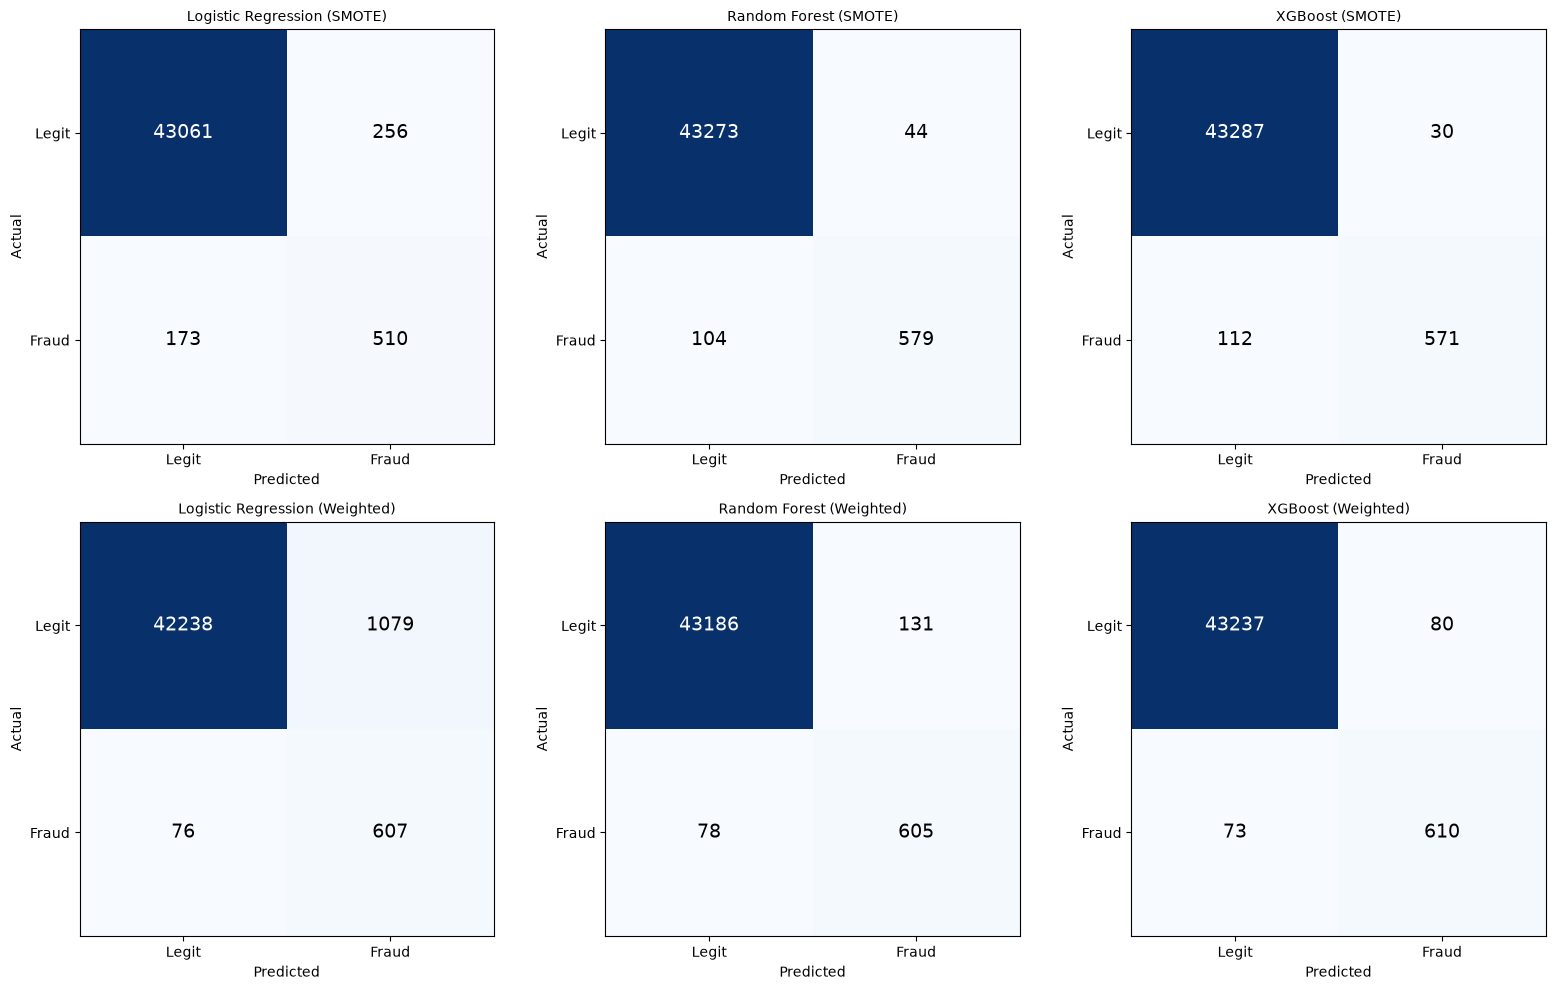


Best model: XGBoost (SMOTE) — PR-AUC: 0.9475


In [5]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt

results = []

def evaluate_model(name, approach, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    results.append({
        'Model': name,
        'Approach': approach,
        'Precision': precision_score(y_eval, y_pred),
        'Recall': recall_score(y_eval, y_pred),
        'F1': f1_score(y_eval, y_pred),
        'ROC-AUC': roc_auc_score(y_eval, y_proba),
        'PR-AUC': average_precision_score(y_eval, y_proba),
    })
    return y_pred, y_proba

# --- Evaluate all SMOTE models ---
for name, model in models_smote.items():
    evaluate_model(name, 'SMOTE', model, X_test_scaled, y_test)

# --- Evaluate all class-weighted models ---
for name, model in models_weighted.items():
    evaluate_model(name, 'Class Weights', model, X_test_scaled, y_test)

results_df = pd.DataFrame(results).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
print("=" * 90)
print("MODEL COMPARISON (sorted by PR-AUC — the right metric for imbalanced fraud data)")
print("=" * 90)
print(results_df.to_string(index=False))

# --- Confusion matrices for all 6 models ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
all_models = {**{f"{k} (SMOTE)": v for k, v in models_smote.items()},
              **{f"{k} (Weighted)": v for k, v in models_weighted.items()}}

for ax, (name, model) in zip(axes.flat, all_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    ax.imshow(cm, cmap='Blues')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Legit', 'Fraud'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Legit', 'Fraud'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

# --- Best model by PR-AUC ---
best_row = results_df.iloc[0]
print(f"\nBest model: {best_row['Model']} ({best_row['Approach']}) — PR-AUC: {best_row['PR-AUC']:.4f}")

# Fraud Scoring API 

In [6]:
import joblib

# --- Select and save the winning model ---
FINAL_MODEL = models_smote['XGBoost']
joblib.dump(FINAL_MODEL, 'fraud_model_xgb_smote.pkl')
joblib.dump(scaler, 'fraud_scaler.pkl')
print("Model + scaler saved.")

# --- Risk thresholds (tune these based on business tolerance for false positives) ---
BLOCK_THRESHOLD = 0.85
REVIEW_THRESHOLD = 0.40

class FraudScoringAPI:
    """
    Production-style fraud scoring pipeline:
    Transaction -> Feature Engineering -> Model -> Fraud Probability -> Risk Classification
    """
    def __init__(self, model, scaler, feature_cols, customer_history):
        self.model = model
        self.scaler = scaler
        self.feature_cols = feature_cols
        self.customer_history = customer_history  # dict: customer_id -> recent txn stats

    def _engineer_features(self, txn: dict) -> pd.DataFrame:
        cid = txn['customer_id']
        hist = self.customer_history.get(cid, {
            'avg_amount': txn['amount'], 'std_amount': 0,
            'last_time': None, 'last_location': None, 'last_amount': txn['amount'],
            'txn_count_1hr': 0, 'txn_count_24hr': 0, 'seen_categories': set()
        })

        ts = pd.to_datetime(txn['timestamp'])
        amount = txn['amount']

        amount_deviation = (amount - hist['avg_amount']) / (hist['std_amount'] + 1e-6)
        amount_deviation = np.clip(amount_deviation, -10, 10)
        amount_to_prev_ratio = amount / (hist['last_amount'] + 1e-6)

        if hist['last_time'] is not None:
            time_since_last_hr = max((ts - hist['last_time']).total_seconds() / 3600, 0.0001)
        else:
            time_since_last_hr = 24.0

        if hist['last_location'] is not None:
            lat1, lon1 = np.radians(hist['last_location'])
            lat2, lon2 = np.radians((txn['latitude'], txn['longitude']))
            dlat, dlon = lat2 - lat1, lon2 - lon1
            a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
            distance_from_prev = 6371 * 2 * np.arcsin(np.sqrt(a))
        else:
            distance_from_prev = 0.0

        hour = ts.hour
        is_odd_hour = 1 if 0 <= hour <= 5 else 0
        day_of_week = ts.dayofweek
        is_weekend = 1 if day_of_week in [5, 6] else 0
        is_rapid_txn = 1 if time_since_last_hr < (60/3600) else 0
        high_velocity_flag = 1 if hist['txn_count_1hr'] >= 4 else 0

        HIGH_RISK = {'crypto_exchange', 'gambling', 'wire_transfer', 'jewelry'}
        is_high_risk_merchant = 1 if txn['merchant_category'] in HIGH_RISK else 0
        is_unusual_merchant = 0 if txn['merchant_category'] in hist['seen_categories'] else 1
        high_distance_flag = 1 if distance_from_prev > 500 else 0
        device_changed = 0  # simplified for single-transaction scoring

        features = {
            'amount': amount,
            'previous_transaction_amount': hist['last_amount'],
            'time_since_last_txn_hr': time_since_last_hr,
            'distance_from_prev_km': distance_from_prev,
            'cust_avg_amount_so_far': hist['avg_amount'],
            'cust_std_amount_so_far': hist['std_amount'],
            'txn_count_last_1hr': hist['txn_count_1hr'],
            'txn_count_last_24hr': hist['txn_count_24hr'],
            'amount_deviation': amount_deviation,
            'amount_to_prev_ratio': amount_to_prev_ratio,
            'hour_of_day': hour,
            'is_odd_hour': is_odd_hour,
            'day_of_week': day_of_week,
            'is_weekend': is_weekend,
            'is_rapid_txn': is_rapid_txn,
            'high_velocity_flag': high_velocity_flag,
            'is_high_risk_merchant': is_high_risk_merchant,
            'is_unusual_merchant_for_customer': is_unusual_merchant,
            'high_distance_flag': high_distance_flag,
            'device_changed': device_changed,
        }
        return pd.DataFrame([features])[self.feature_cols]

    def score(self, txn: dict) -> dict:
        feat_df = self._engineer_features(txn)
        feat_scaled = pd.DataFrame(self.scaler.transform(feat_df), columns=self.feature_cols)

        fraud_probability = float(self.model.predict_proba(feat_scaled)[0, 1])

        if fraud_probability >= BLOCK_THRESHOLD:
            decision = 'BLOCK'
        elif fraud_probability >= REVIEW_THRESHOLD:
            decision = 'REVIEW'
        else:
            decision = 'ALLOW'

        return {
            'transaction_id': txn.get('transaction_id', 'N/A'),
            'customer_id': txn['customer_id'],
            'fraud_probability': round(fraud_probability, 4),
            'risk_decision': decision,
        }


# --- Build a lightweight customer_history snapshot from the training data ---
customer_history = {}
for cid, group in df.groupby('customer_id'):
    group = group.sort_values('timestamp')
    last = group.iloc[-1]
    customer_history[cid] = {
        'avg_amount': group['amount'].mean(),
        'std_amount': group['amount'].std() if len(group) > 1 else 0,
        'last_time': last['timestamp'],
        'last_location': (last['latitude'], last['longitude']),
        'last_amount': last['amount'],
        'txn_count_1hr': 1,
        'txn_count_24hr': min(len(group), 5),
        'seen_categories': set(group['merchant_category'].unique()),
    }

# --- Instantiate the API ---
fraud_api = FraudScoringAPI(FINAL_MODEL, scaler, FEATURE_COLS, customer_history)

# --- Demo: score a few sample transactions ---
sample_legit = {
    'transaction_id': 'TXN_TEST_001',
    'customer_id': df['customer_id'].iloc[0],
    'amount': 45.00,
    'timestamp': '2025-06-15 14:30:00',
    'merchant_category': 'grocery',
    'latitude': df['latitude'].iloc[0],
    'longitude': df['longitude'].iloc[0],
    'device': 'mobile_ios',
}

sample_fraud = {
    'transaction_id': 'TXN_TEST_002',
    'customer_id': df['customer_id'].iloc[0],
    'amount': 4500.00,
    'timestamp': '2025-06-15 03:12:00',
    'merchant_category': 'crypto_exchange',
    'latitude': 51.5,
    'longitude': -0.12,
    'device': 'web_chrome',
}

print("=== Sample Scoring Results ===")
print(fraud_api.score(sample_legit))
print(fraud_api.score(sample_fraud))

Model + scaler saved.
=== Sample Scoring Results ===
{'transaction_id': 'TXN_TEST_001', 'customer_id': 'CUST_00000', 'fraud_probability': 0.0, 'risk_decision': 'ALLOW'}
{'transaction_id': 'TXN_TEST_002', 'customer_id': 'CUST_00000', 'fraud_probability': 0.9999, 'risk_decision': 'BLOCK'}
